ASSIGNMENT – 7

Course: Generative AI

Topic: Creating and Fixing Mode Collapse in a GAN

Name: Ashif Hussain

Program: BCA – Semester V

Department: Computer Applications

University: Alliance University

In [1]:
# Step 1: Importing Library

# Import PyTorch main library
import torch

# Import neural network tools (layers like Conv2d, BatchNorm2d)
import torch.nn as nn

# Import optimizer (helps the model learn)
import torch.optim as optim

# Import tools to load and prepare the dataset
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Import tools to show images and graphs
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Step 2: Set the Basic Parameters

# Size of the random noise vector (input to generator)
noise_dim = 100

# Number of images processed together in one step
batch_size = 128

# Size of the images (Fashion-MNIST is 28x28, we resize to 64x64)
image_size = 64

# Number of channels in image (1 = grayscale)
channels = 1

# Number of times we go through the full dataset (assignment says 15-20)
num_epochs = 20

# BROKEN SETTING: Learning rate is VERY HIGH on purpose (normal was 0.0002)
# This makes training unstable and can cause mode collapse
lr = 0.01

# Device to run the code on (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [8]:
# Step 3: Load the Fashion-MNIST Data

# Steps to prepare each image before feeding to the model
transform = transforms.Compose([
    transforms.Resize(image_size),          # resize image to 64x64
    transforms.ToTensor(),                  # convert image to tensor (numbers)
    transforms.Normalize((0.5,), (0.5,))    # scale pixel values from -1 to 1
])

# Download and load the Fashion-MNIST training dataset
dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Load data in small batches, shuffled randomly
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print("Total training images:", len(dataset))

Total training images: 60000


In [15]:
# Step 4: Build the BROKEN Generator

# BROKEN SETTINGS (on purpose):
# 1) Much smaller layers (128, 64, 32, 16 instead of 512, 256, 128, 64) = low capacity
# 2) NO BatchNorm layers = unstable training

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Input: noise (100, 1, 1) -> Output: (128, 4, 4)
            nn.ConvTranspose2d(noise_dim, 128, kernel_size=4, stride=1, padding=0, bias=False),
            nn.ReLU(True),

            # (128, 4, 4) -> (64, 8, 8)
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.ReLU(True),

            # (64, 8, 8) -> (32, 16, 16)
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1, bias=False),
            nn.ReLU(True),

            # (32, 16, 16) -> (16, 32, 32)
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1, bias=False),
            nn.ReLU(True),

            # (16, 32, 32) -> (1, 64, 64) final image
            nn.ConvTranspose2d(16, channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()   # squashes output between -1 and 1
        )

    def forward(self, input):
        return self.main(input)

# Create the generator and move it to device (GPU/CPU)
generator = Generator().to(device)
print(generator)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 128, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): ReLU(inplace=True)
    (8): ConvTranspose2d(16, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): Tanh()
  )
)


In [16]:
# Step 5: Build the Discriminator

# The Discriminator looks at an image and decides if it is real or fake.
# We keep it the same as Assignment 4 (it stays strong, which makes the generator struggle)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input: (1, 64, 64) -> (64, 32, 32)
            nn.Conv2d(channels, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # (64, 32, 32) -> (128, 16, 16)
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # (128, 16, 16) -> (256, 8, 8)
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # (256, 8, 8) -> (512, 4, 4)
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            # (512, 4, 4) -> (1, 1, 1) final decision
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0, bias=False),
        )

    def forward(self, input):
        return self.main(input)

# Create the discriminator and move it to device
discriminator = Discriminator().to(device)

# Sigmoid turns the raw score into a probability between 0 and 1
sigmoid = nn.Sigmoid()

print(discriminator)

Discriminator(
  (main): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
  )
)


In [11]:
# Step 6: Loss Function and Optimizers

# Loss function: Binary Cross Entropy (measures how wrong the predictions are)
criterion = nn.BCELoss()

# Labels (same convention as Assignment 4): real = 0, fake = 1
real_label = 0
fake_label = 1

# Optimizer for Discriminator (uses the HIGH lr = 0.01 from Step 2)
optimizerD = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

# Optimizer for Generator (also uses the HIGH lr = 0.01 from Step 2)
optimizerG = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))

print("Loss and optimizers ready. Learning rate =", lr)

Loss and optimizers ready. Learning rate = 0.01


In [17]:
# FIX: Step 6 again (Loss Function and Optimizers, improved)

# Loss function (same as before)
criterion = nn.BCELoss()

# FIX 1: Label smoothing
# Before: real label was exactly 0. Now it is 0.1 (a softer label).
# This stops the Discriminator from becoming too confident.
real_label = 0.1
fake_label = 1

# FIX 2: Different (and small) learning rates for the two models
# Before: both were 0.01 (too high). Now they are small, and Generator is faster.
lrG = 0.0002
lrD = 0.0001

# New optimizers
optimizerD = optim.Adam(discriminator.parameters(), lr=lrD, betas=(0.5, 0.999))
optimizerG = optim.Adam(generator.parameters(), lr=lrG, betas=(0.5, 0.999))

# Clear the old loss lists
G_losses = []
D_losses = []

print("Fix applied. real_label =", real_label, "| lrG =", lrG, "| lrD =", lrD)

Fix applied. real_label = 0.1 | lrG = 0.0002 | lrD = 0.0001


In [12]:
# Step 7: Training Function (one epoch)

# Lists to store loss values for plotting later
G_losses = []
D_losses = []

def train_one_epoch(dataloader):
    for i, data in enumerate(dataloader):

        ############################
        # (1) Train Discriminator
        ############################
        discriminator.zero_grad()

        # --- Train with real images ---
        real_images = data[0].to(device)
        b_size = real_images.size(0)
        labels = torch.full((b_size,), real_label, dtype=torch.float, device=device)

        output = discriminator(real_images).view(-1)
        output = sigmoid(output)
        lossD_real = criterion(output, labels)
        lossD_real.backward()

        # --- Train with fake images ---
        noise = torch.randn(b_size, noise_dim, 1, 1, device=device)
        fake_images = generator(noise)
        labels.fill_(fake_label)

        output = discriminator(fake_images.detach()).view(-1)   # detach so generator is not updated here
        output = sigmoid(output)
        lossD_fake = criterion(output, labels)
        lossD_fake.backward()

        # Total discriminator loss, then update the discriminator
        lossD = lossD_real + lossD_fake
        optimizerD.step()

        ############################
        # (2) Train Generator
        ############################
        generator.zero_grad()

        # Generator wants the discriminator to think fake images are REAL (label 0)
        labels.fill_(real_label)
        output = discriminator(fake_images).view(-1)
        output = sigmoid(output)
        lossG = criterion(output, labels)
        lossG.backward()
        optimizerG.step()

        # Save losses for the graph
        G_losses.append(lossG.item())
        D_losses.append(lossD.item())

    return lossD.item(), lossG.item()

print("Training function ready.")

Training function ready.


Epoch [1/20]  Loss D: 0.0000  Loss G: 100.0000
Epoch [2/20]  Loss D: 0.0000  Loss G: 100.0000
Epoch [3/20]  Loss D: 0.0000  Loss G: 100.0000
Epoch [4/20]  Loss D: 0.0000  Loss G: 100.0000
Epoch [5/20]  Loss D: 0.0000  Loss G: 100.0000


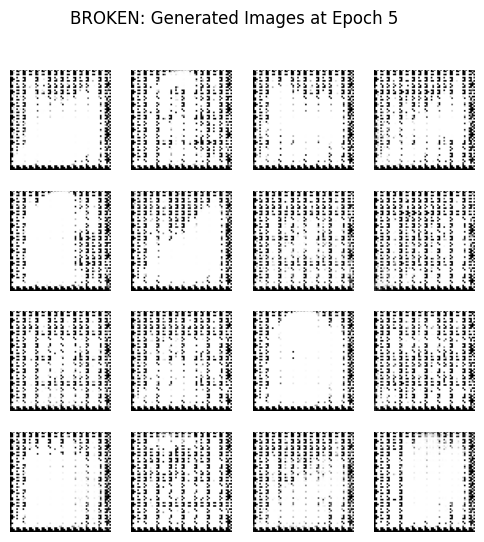

Epoch [6/20]  Loss D: 0.0000  Loss G: 100.0000
Epoch [7/20]  Loss D: 0.0000  Loss G: 100.0000
Epoch [8/20]  Loss D: 0.0000  Loss G: 100.0000
Epoch [9/20]  Loss D: 0.0000  Loss G: 100.0000
Epoch [10/20]  Loss D: 0.0000  Loss G: 100.0000


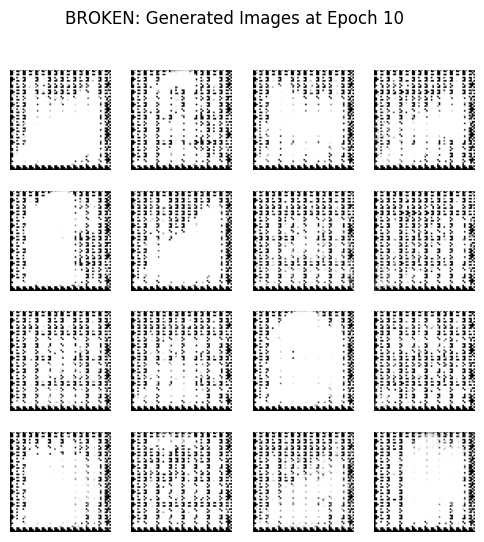

Epoch [11/20]  Loss D: 0.0000  Loss G: 100.0000
Epoch [12/20]  Loss D: 0.0000  Loss G: 100.0000
Epoch [13/20]  Loss D: 0.0000  Loss G: 100.0000
Epoch [14/20]  Loss D: 0.0000  Loss G: 100.0000
Epoch [15/20]  Loss D: 0.0000  Loss G: 100.0000


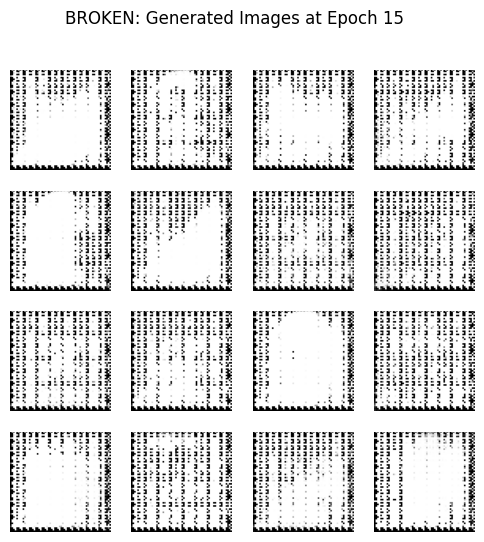

Epoch [16/20]  Loss D: 0.0000  Loss G: 100.0000
Epoch [17/20]  Loss D: 0.0000  Loss G: 100.0000
Epoch [18/20]  Loss D: 0.0000  Loss G: 100.0000
Epoch [19/20]  Loss D: 0.0000  Loss G: 100.0000
Epoch [20/20]  Loss D: 0.0000  Loss G: 100.0000


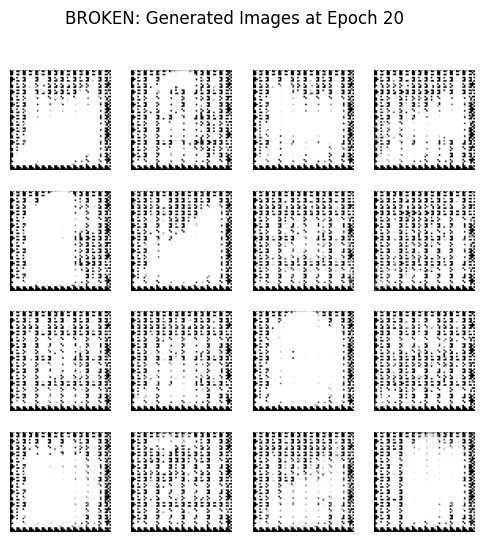

In [13]:
# Step 8: Train the BROKEN Model for 20 Epochs (show 4x4 images every 5 epochs)

# Fixed noise so we can compare the SAME noise across different epochs
fixed_noise = torch.randn(16, noise_dim, 1, 1, device=device)

# Function to show and save a 4x4 grid of generated images
def save_image_grid(epoch, prefix):
    with torch.no_grad():
        fake = generator(fixed_noise).cpu()

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        img = fake[i][0] * 0.5 + 0.5   # undo normalization
        ax.imshow(img, cmap="gray")
        ax.axis("off")
    plt.suptitle(f"{prefix}: Generated Images at Epoch {epoch}")
    plt.savefig(f"{prefix}_epoch_{epoch}.png")
    plt.show()

# Main training loop
for epoch in range(1, num_epochs + 1):
    lossD, lossG = train_one_epoch(dataloader)
    print(f"Epoch [{epoch}/{num_epochs}]  Loss D: {lossD:.4f}  Loss G: {lossG:.4f}")

    # Show image grid every 5 epochs
    if epoch % 5 == 0:
        save_image_grid(epoch, "BROKEN")

Epoch [1/20]  Loss D: 0.4060  Loss G: 4.2481
Epoch [2/20]  Loss D: 0.3879  Loss G: 4.0217
Epoch [3/20]  Loss D: 0.3670  Loss G: 4.0733
Epoch [4/20]  Loss D: 0.3545  Loss G: 5.2940
Epoch [5/20]  Loss D: 0.3596  Loss G: 4.9400


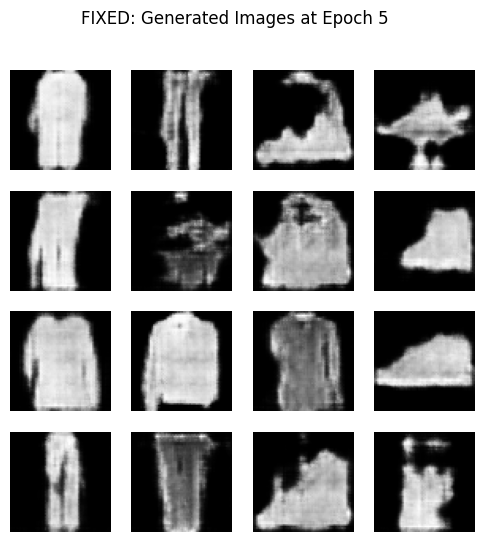

Epoch [6/20]  Loss D: 0.3577  Loss G: 4.2549
Epoch [7/20]  Loss D: 0.3640  Loss G: 4.3977
Epoch [8/20]  Loss D: 0.3382  Loss G: 5.5785
Epoch [9/20]  Loss D: 0.3520  Loss G: 4.2838
Epoch [10/20]  Loss D: 0.3660  Loss G: 3.7417


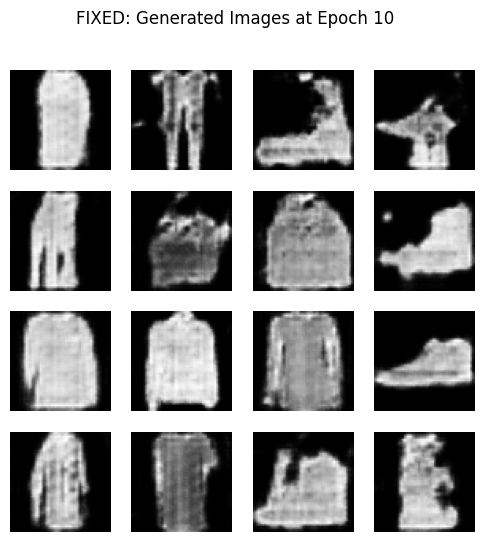

Epoch [11/20]  Loss D: 0.3650  Loss G: 4.3371
Epoch [12/20]  Loss D: 0.3554  Loss G: 4.1338
Epoch [13/20]  Loss D: 0.3430  Loss G: 5.3719
Epoch [14/20]  Loss D: 0.3514  Loss G: 4.8341
Epoch [15/20]  Loss D: 0.3508  Loss G: 5.7057


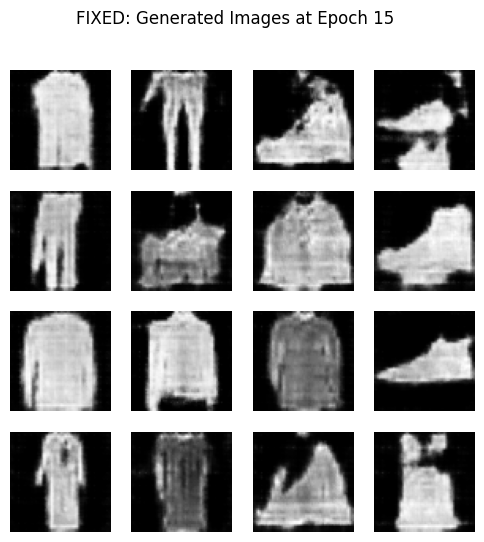

Epoch [16/20]  Loss D: 0.3482  Loss G: 5.8356
Epoch [17/20]  Loss D: 0.3724  Loss G: 4.0182
Epoch [18/20]  Loss D: 0.3375  Loss G: 6.7924
Epoch [19/20]  Loss D: 0.3286  Loss G: 7.0816
Epoch [20/20]  Loss D: 0.3615  Loss G: 6.2780


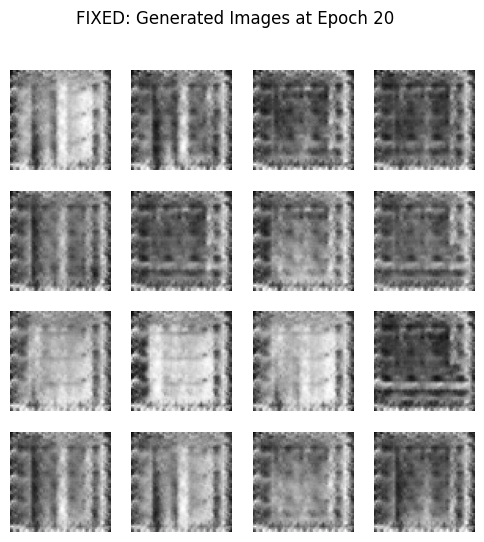

In [19]:
# Train the FIXED Model for 20 Epochs (show 4x4 images every 5 epochs)

for epoch in range(1, num_epochs + 1):
    lossD, lossG = train_one_epoch(dataloader)
    print(f"Epoch [{epoch}/{num_epochs}]  Loss D: {lossD:.4f}  Loss G: {lossG:.4f}")

    # Show image grid every 5 epochs
    if epoch % 5 == 0:
        save_image_grid(epoch, "FIXED")

Short Explanation

1. What modification caused the model to perform poorly?
I increased the learning rate from 0.0002 to 0.01. I also reduced the capacity of the Generator and removed Batch Normalization. These changes made the GAN training unstable and caused the Generator to produce very similar images. This behavior is called mode collapse.

2. What did the generated images look like?
The generated images were very similar to each other and did not show enough variety. Some images also looked unclear or poorly formed. This showed that the Generator was not learning different patterns from the Fashion-MNIST dataset properly.

3. Which technique did you use to improve the model?
I used label smoothing and different learning rates for the Generator and Discriminator. I changed the real label from 0 to 0.1 and used 0.0002 for the Generator and 0.0001 for the Discriminator.

4. Did the solution improve the output? Why?
Yes, the output improved after applying these techniques. The training became more stable and the generated images showed better quality and more variation. Label smoothing prevented the Discriminator from becoming too confident, while the smaller and different learning rates helped the Generator and Discriminator learn in a more balanced way.

Conclusion

The experiment showed that unstable GAN training can lead to mode collapse, where the Generator produces very similar outputs. By using label smoothing and suitable learning rates, the training became more stable and the quality and variety of generated images improved.